# RDD2022 — Comparativa de experimentos DINOv1

Notebook para comparar los resultados de los tres experimentos realizados con DINOv1:

| Exp | dropout | épocas | hidden_dim |
|-----|---------|--------|------------|
| 1   | 0.3     | 80     | 512        |
| 2   | 0.5     | 80     | 512        |
| 3   | 0.5     | 20     | 256        |


In [ ]:
# Instalar dependencias si es necesario (descomentar en Colab)
# !pip install matplotlib numpy


In [7]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# ── Estilo general ──────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":       "monospace",
    "figure.facecolor":  "#0F1117",
    "axes.facecolor":    "#171B26",
    "text.color":        "#E8EAF0",
    "axes.labelcolor":   "#E8EAF0",
    "xtick.color":       "#9AA0B4",
    "ytick.color":       "#9AA0B4",
    "axes.edgecolor":    "#2D3348",
    "grid.color":        "#2D3348",
    "axes.grid":         True,
    "grid.alpha":        0.25,
    "grid.linestyle":    "--",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

COLORS = {
    "exp1": "#378ADD",
    "exp2": "#E76F51",
    "exp3": "#2A9D8F",
    "D00":  "#F4A261",
    "D10":  "#2A9D8F",
    "D20":  "#E76F51",
}

CLASSES = ["D00", "D10", "D20"]

print("Imports correctos ✅")


Imports correctos ✅


## 1. Carga de los training reports

Ajusta las rutas a donde tengas guardados los tres archivos JSON.

In [8]:
# ── Ajusta estas rutas ──────────────────────────────────────────────
# En local (Windows):
#REPORT_PATHS = {
 #   "Exp1 d=0.3 80ep h=512": r"C:\Users\pablo\Downloads\PASD\features\models\dinov1\training_report.json",
  #  "Exp2 d=0.5 80ep h=512": r"C:\Users\pablo\Downloads\PASD\features\models\dinov1\training_report_dropout05.json",
   # "Exp3 d=0.5 20ep h=256": r"C:\Users\pablo\Downloads\PASD\features\models\dinov1\training_report_20_epochs_256_hidden.json",

# En Colab con Google Drive:
from google.colab import drive
drive.mount('/content/drive')
REPORT_PATHS = {
     "Exp1 d=0.3 80ep h=512": "/content/drive/MyDrive/PASD BLOG/models/dinov1_MLP/training_report.json",
     "Exp2 d=0.5 80ep h=512": "/content/drive/MyDrive/PASD BLOG/models/dinov1_MLP/training_report_dropout05.json",
     "Exp3 d=0.5 20ep h=256": "/content/drive/MyDrive/PASD BLOG/models/dinov1_MLP/training_report_20_epochs_256_hidden.json",
 }

# ── Carga ───────────────────────────────────────────────────────────
reports = {}
for name, path in REPORT_PATHS.items():
    with open(path, encoding="utf-8") as f:
        reports[name] = json.load(f)
    n_ep = len(reports[name]["history"])
    mf1  = reports[name]["test_metrics"]["macro_f1"]
    print(f"  {name}: {n_ep} épocas | Macro F1 test = {mf1:.4f} ✅")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Exp1 d=0.3 80ep h=512: 62 épocas | Macro F1 test = 0.7254 ✅
  Exp2 d=0.5 80ep h=512: 66 épocas | Macro F1 test = 0.7249 ✅
  Exp3 d=0.5 20ep h=256: 20 épocas | Macro F1 test = 0.7298 ✅


## 2. Tabla resumen de resultados

In [ ]:
print(f"{'Experimento':<28} {'Macro F1':>9} {'D00 F1':>8} {'D10 F1':>8} {'D20 F1':>8} {'Exact Acc':>10} {'Train F1':>10} {'Val loss':>10}")
print("─" * 100)

for name, rep in reports.items():
    tm   = rep["test_metrics"]
    hist = rep["history"]
    train_f1_final = hist[-1]["train_f1"]
    val_loss_final = hist[-1]["val_loss"]
    print(
        f"  {name:<26} "
        f"{tm['macro_f1']:>9.4f} "
        f"{tm['D00']['f1']:>8.4f} "
        f"{tm['D10']['f1']:>8.4f} "
        f"{tm['D20']['f1']:>8.4f} "
        f"{tm['exact_accuracy']:>10.4f} "
        f"{train_f1_final:>10.4f} "
        f"{val_loss_final:>10.4f} "
    )


Experimento                   Macro F1   D00 F1   D10 F1   D20 F1  Exact Acc   Train F1   Val loss
────────────────────────────────────────────────────────────────────────────────────────────────────
  Exp1 d=0.3 80ep h=512         0.7254   0.8200   0.6036   0.7526     0.5155     0.9633     0.8116 
  Exp2 d=0.5 80ep h=512         0.7249   0.8104   0.6032   0.7612     0.5118     0.9157     0.6838 
  Exp3 d=0.5 20ep h=256         0.7298   0.8053   0.6157   0.7684     0.5004     0.8216     0.5401 


## 3. Curvas de entrenamiento

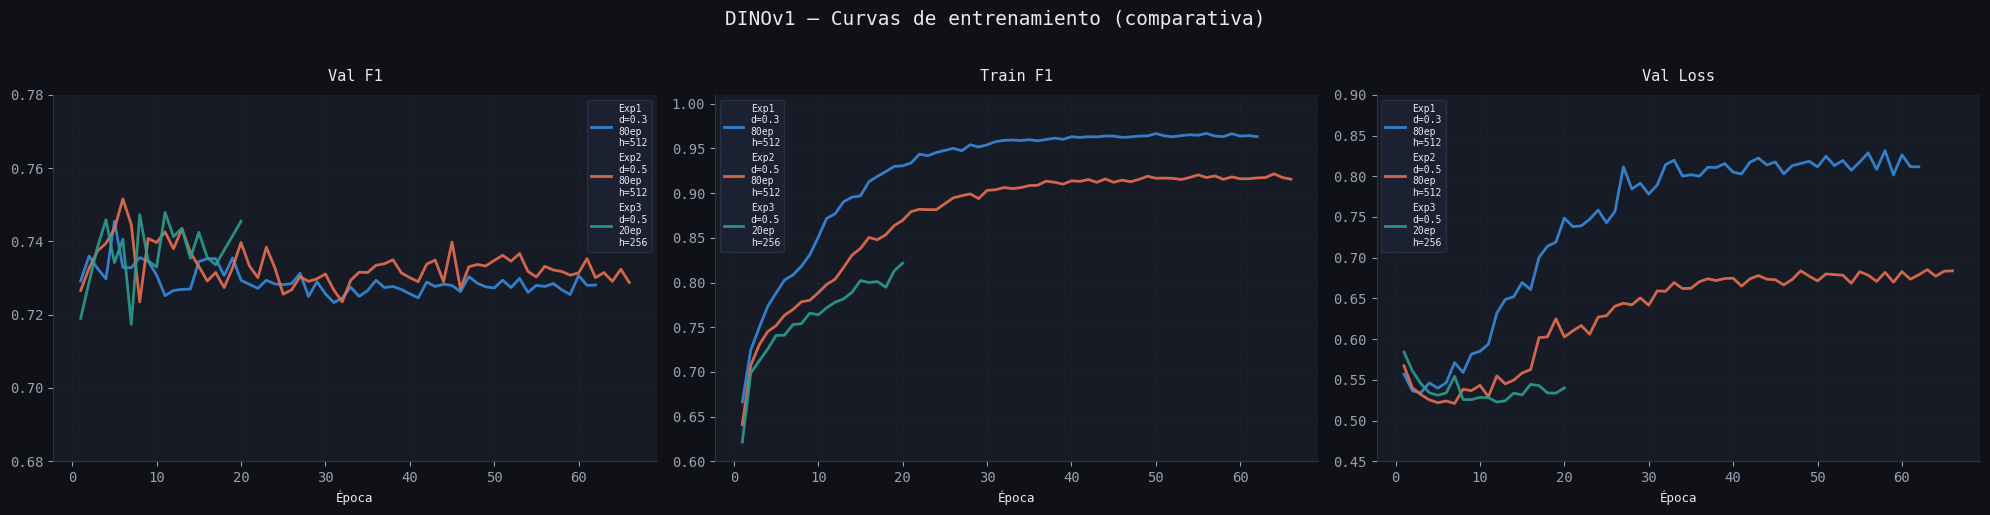

Figura guardada: curvas_entrenamiento.png


In [ ]:
exp_colors = list(COLORS.values())[:3]
exp_names  = list(reports.keys())

fig, axes = plt.subplots(1, 3, figsize=(20, 5), facecolor="#0F1117")
fig.suptitle("DINOv1 — Curvas de entrenamiento (comparativa)", fontsize=14, color="#E8EAF0", y=1.02)

titles   = ["Val F1", "Train F1", "Val Loss"]
keys_y   = ["val_f1", "train_f1", "val_loss"]
y_limits = [(0.68, 0.78), (0.60, 1.01), (0.45, 0.90)]

for ax, title, key, ylim in zip(axes, titles, keys_y, y_limits):
    for (name, rep), color in zip(reports.items(), exp_colors):
        epochs = [h["epoch"]  for h in rep["history"]]
        values = [h[key]      for h in rep["history"]]
        ax.plot(epochs, values, color=color, linewidth=2,
                label=name.replace(" ", "\n"), alpha=0.9)

    ax.set_title(title, fontsize=11, color="#E8EAF0", pad=10)
    ax.set_xlabel("Época", fontsize=9)
    ax.set_ylim(ylim)
    ax.legend(fontsize=7, facecolor="#1E2336", edgecolor="#2D3348",
              labelcolor="#E8EAF0", loc="best")

plt.tight_layout()
plt.savefig("curvas_entrenamiento.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("Figura guardada: curvas_entrenamiento.png")


## 4. F1 por clase en test

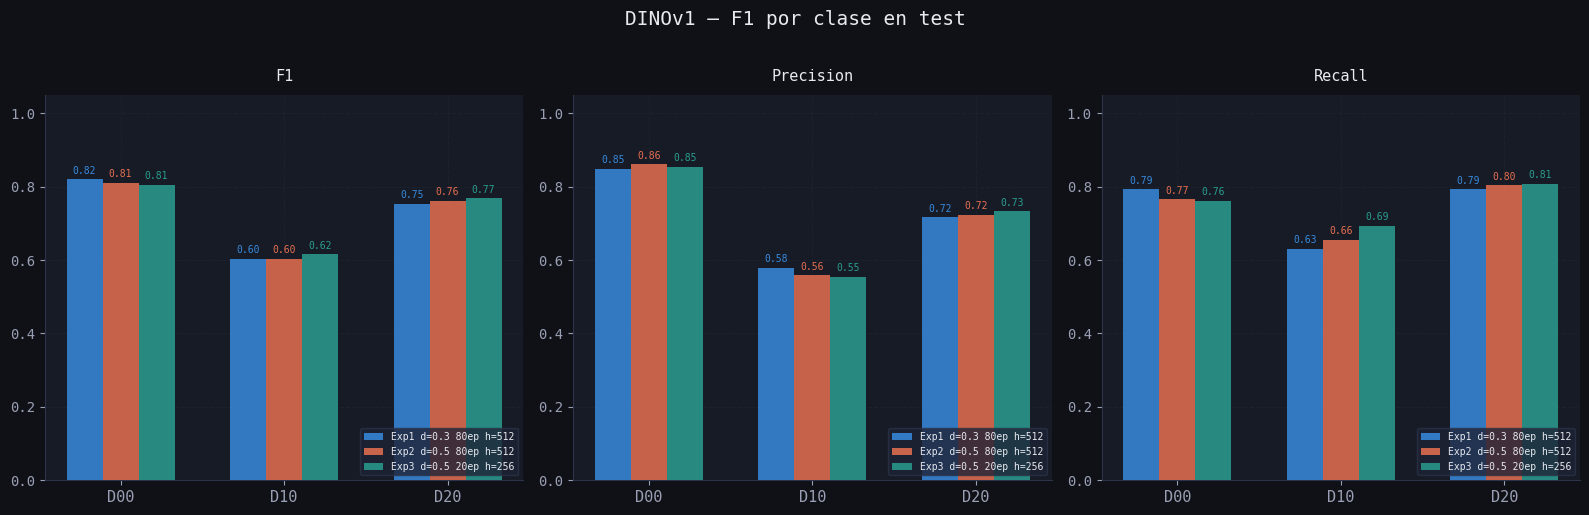

Figura guardada: f1_por_clase.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor="#0F1117")
fig.suptitle("DINOv1 — F1 por clase en test", fontsize=14, color="#E8EAF0", y=1.02)

metrics_to_plot = ["f1", "precision", "recall"]
metric_titles   = ["F1", "Precision", "Recall"]

for ax, metric, title in zip(axes, metrics_to_plot, metric_titles):
    x      = np.arange(len(CLASSES))
    n_exp  = len(reports)
    width  = 0.22
    offset = np.linspace(-(n_exp - 1) / 2, (n_exp - 1) / 2, n_exp) * width

    for (name, rep), color, off in zip(reports.items(), exp_colors, offset):
        vals = [rep["test_metrics"][cls][metric] for cls in CLASSES]
        bars = ax.bar(x + off, vals, width, color=color, alpha=0.85,
                      label=name, zorder=3, linewidth=0)
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                    f"{h:.2f}", ha="center", va="bottom",
                    fontsize=7, color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(CLASSES, fontsize=11)
    ax.set_title(title, fontsize=11, color="#E8EAF0", pad=10)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7, facecolor="#1E2336", edgecolor="#2D3348",
              labelcolor="#E8EAF0", loc="lower right")

plt.tight_layout()
plt.savefig("f1_por_clase.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("Figura guardada: f1_por_clase.png")


## 5. Análisis de overfitting

Diferencia entre train F1 y val F1 por época.
Cuanto más pequeña, menos overfitting.

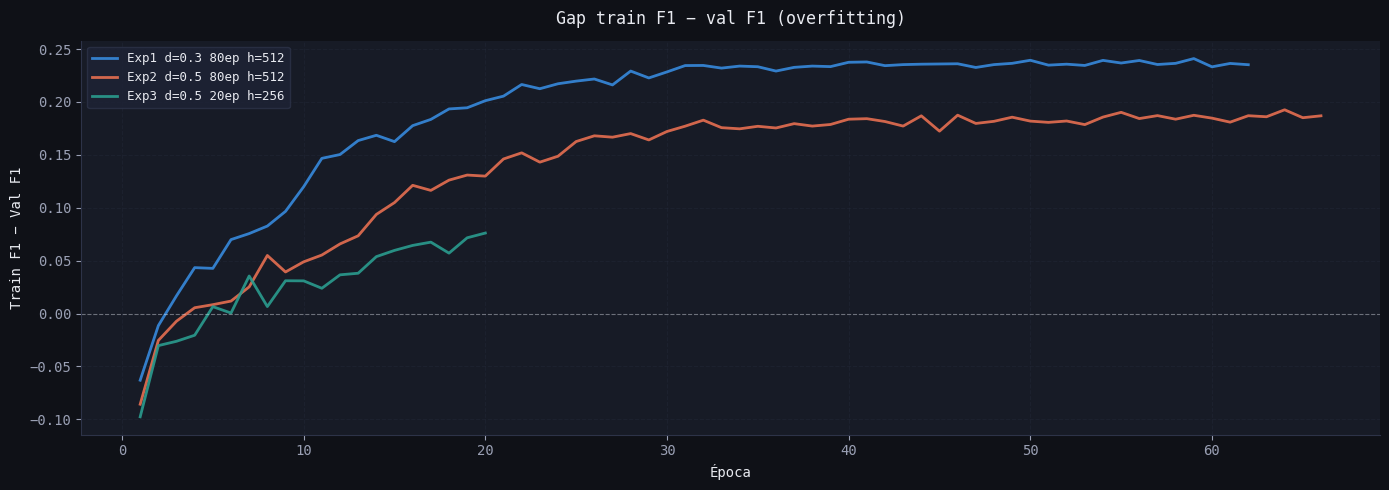

Figura guardada: overfitting_gap.png


In [ ]:
fig, ax = plt.subplots(figsize=(14, 5), facecolor="#0F1117")

for (name, rep), color in zip(reports.items(), exp_colors):
    epochs = [h["epoch"]                    for h in rep["history"]]
    gap    = [h["train_f1"] - h["val_f1"]   for h in rep["history"]]
    ax.plot(epochs, gap, color=color, linewidth=2, label=name, alpha=0.9)

ax.axhline(0, color="#E8EAF0", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_title("Gap train F1 − val F1 (overfitting)", fontsize=12, color="#E8EAF0", pad=12)
ax.set_xlabel("Época", fontsize=10)
ax.set_ylabel("Train F1 − Val F1", fontsize=10)
ax.legend(fontsize=9, facecolor="#1E2336", edgecolor="#2D3348", labelcolor="#E8EAF0")

plt.tight_layout()
plt.savefig("overfitting_gap.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("Figura guardada: overfitting_gap.png")


## 6. Mejor época por experimento (según val F1)

In [ ]:
print(f"{'Experimento':<30} {'Mejor época':>12} {'Mejor val F1':>14} {'val F1 final':>14}")
print("─" * 75)

for name, rep in reports.items():
    hist     = rep["history"]
    best     = max(hist, key=lambda h: h["val_f1"])
    last_vf1 = hist[-1]["val_f1"]
    print(
        f"  {name:<28} "
        f"{best['epoch']:>12} "
        f"{best['val_f1']:>14.4f} "
        f"{last_vf1:>14.4f}"
    )

print()
print("Nota: si 'mejor época' << nº total de épocas → overfitting temprano.")


Experimento                     Mejor época   Mejor val F1   val F1 final
───────────────────────────────────────────────────────────────────────────
  Exp1 d=0.3 80ep h=512                   5         0.7455         0.7281
  Exp2 d=0.5 80ep h=512                   6         0.7516         0.7288
  Exp3 d=0.5 20ep h=256                  11         0.7479         0.7455

Nota: si 'mejor época' << nº total de épocas → overfitting temprano.


## 7. Conclusión y siguiente paso

Los tres experimentos convergen en un Macro F1 test de ~0.725-0.730.

**Patrón observado:**
- D00 estable en ~0.82 (clase más fácil, más ejemplos)
- D20 mejora progresivamente: 0.753 → 0.761 → 0.768
- D10 sigue siendo el cuello de botella: ~0.60-0.62

La convergencia en el mismo techo de val F1 (~0.73-0.75) indica que
el límite no son los hiperparámetros sino las propias features de DINOv1.

**Siguiente paso: DINOv2** con la configuración del Exp3 como baseline:
```bash
python train_detector.py \
    --features C:/features/dinov2 \
    --output C:/models/dinov2 \
    --epochs 20 --dropout 0.5 --hidden-dim 256
```


---
## 8. DINOv1 vs DINOv2 — Mismos hiperparámetros (d=0.5, 20ep, h=256)

Comparativa controlada: el único factor que cambia son las **features** del backbone.

| | DINOv1 Exp3 | DINOv2 |
|---|---|---|
| Backbone | ViT-S/16 DINOv1 | ViT-S/14 DINOv2 |
| Dropout | 0.5 | 0.5 |
| Épocas | 20 | 20 |
| Hidden dim | 256 | 256 |

In [ ]:
# ── Ruta al report de DINOv2 (mismos hiperparámetros que Exp3: d=0.5, 20ep, h=256) ──
#DINOV2_PATH = r"C:\Users\pablo\Downloads\PASD\features\models\dinov2\training_report.json"

# En Colab con Google Drive:
DINOV2_PATH = "/content/drive/MyDrive/PASD BLOG/models/dinov2_MLP/training_report.json"

with open(DINOV2_PATH, encoding="utf-8") as f:
    rep_v2 = json.load(f)

rep_v1   = reports["Exp3 d=0.5 20ep h=256"]  # referencia al Exp3 ya cargado
COLOR_V1 = "#2A9D8F"   # mismo color que Exp3 en la sección anterior
COLOR_V2 = "#C084FC"   # violeta para DINOv2

n_ep_v2 = len(rep_v2["history"])
mf1_v1  = rep_v1["test_metrics"]["macro_f1"]
mf1_v2  = rep_v2["test_metrics"]["macro_f1"]
print(f"  DINOv1 Exp3 (d=0.5 20ep h=256): Macro F1 test = {mf1_v1:.4f} ✅")
print(f"  DINOv2      (d=0.5 20ep h=256): {n_ep_v2} épocas | Macro F1 test = {mf1_v2:.4f} ✅")


  DINOv1 Exp3 (d=0.5 20ep h=256): Macro F1 test = 0.7298 ✅
  DINOv2      (d=0.5 20ep h=256): 20 épocas | Macro F1 test = 0.7523 ✅


In [ ]:
print(f"{'Modelo':<28} {'Macro F1':>9} {'D00 F1':>8} {'D10 F1':>8} {'D20 F1':>8} {'Exact Acc':>10} {'Train F1':>10} {'Val loss':>10}")
print("─" * 100)

for label, rep in [("DINOv1 d=0.5 20ep h=256", rep_v1), ("DINOv2 d=0.5 20ep h=256", rep_v2)]:
    tm   = rep["test_metrics"]
    hist = rep["history"]
    print(
        f"  {label:<26} "
        f"{tm['macro_f1']:>9.4f} "
        f"{tm['D00']['f1']:>8.4f} "
        f"{tm['D10']['f1']:>8.4f} "
        f"{tm['D20']['f1']:>8.4f} "
        f"{tm['exact_accuracy']:>10.4f} "
        f"{hist[-1]['train_f1']:>10.4f} "
        f"{hist[-1]['val_loss']:>10.4f} "
    )


Modelo                        Macro F1   D00 F1   D10 F1   D20 F1  Exact Acc   Train F1   Val loss
────────────────────────────────────────────────────────────────────────────────────────────────────
  DINOv1 d=0.5 20ep h=256       0.7298   0.8053   0.6157   0.7684     0.5004     0.8216     0.5401 
  DINOv2 d=0.5 20ep h=256       0.7523   0.8119   0.6562   0.7890     0.5208     0.7756     0.4940 


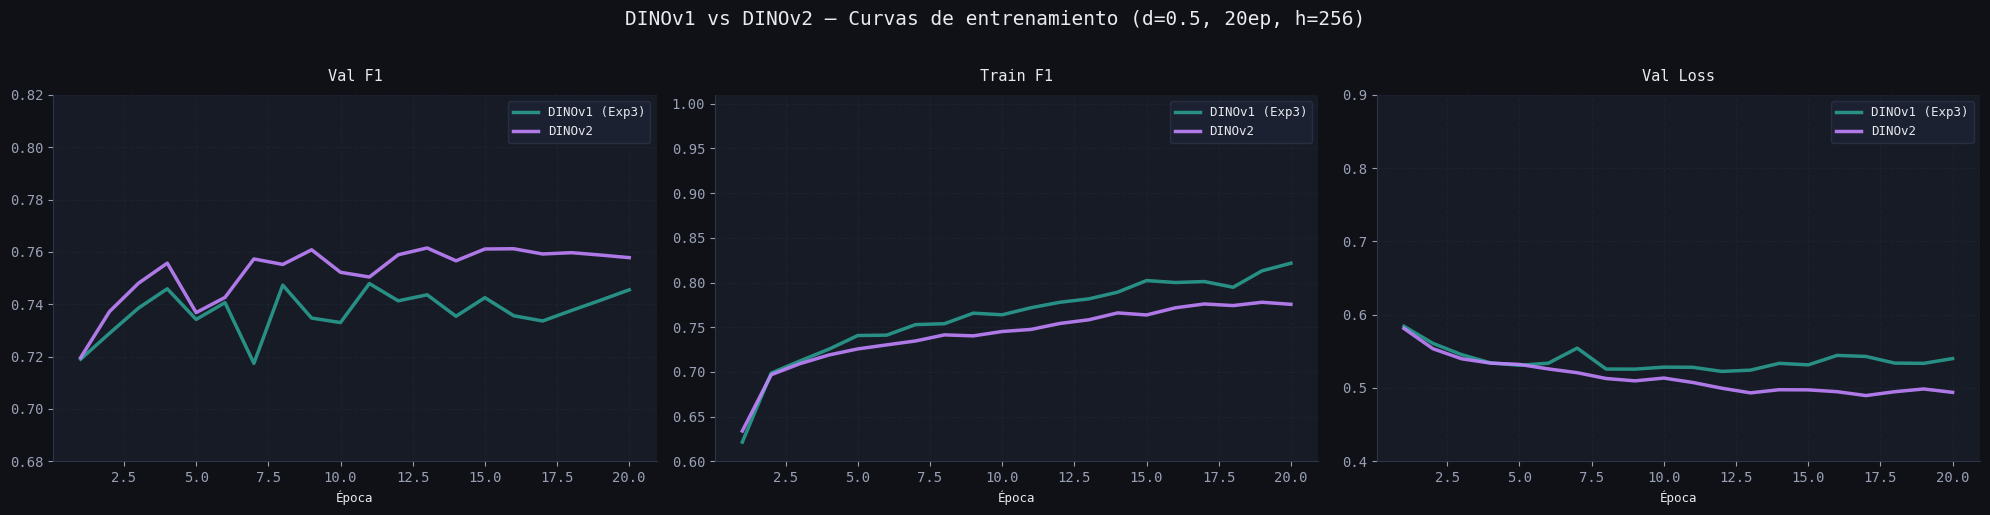

Figura guardada: dinov1_vs_v2_curvas.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), facecolor="#0F1117")
fig.suptitle("DINOv1 vs DINOv2 — Curvas de entrenamiento (d=0.5, 20ep, h=256)",
             fontsize=14, color="#E8EAF0", y=1.02)

titles   = ["Val F1", "Train F1", "Val Loss"]
keys_y   = ["val_f1", "train_f1", "val_loss"]
y_limits = [(0.68, 0.82), (0.60, 1.01), (0.40, 0.90)]

for ax, title, key, ylim in zip(axes, titles, keys_y, y_limits):
    for label, rep, color in [
        ("DINOv1 (Exp3)", rep_v1, COLOR_V1),
        ("DINOv2",        rep_v2, COLOR_V2),
    ]:
        epochs = [h["epoch"] for h in rep["history"]]
        values = [h[key]     for h in rep["history"]]
        ax.plot(epochs, values, color=color, linewidth=2.5, label=label, alpha=0.9)

    ax.set_title(title, fontsize=11, color="#E8EAF0", pad=10)
    ax.set_xlabel("Época", fontsize=9)
    ax.set_ylim(ylim)
    ax.legend(fontsize=9, facecolor="#1E2336", edgecolor="#2D3348",
              labelcolor="#E8EAF0", loc="best")

plt.tight_layout()
plt.savefig("dinov1_vs_v2_curvas.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("Figura guardada: dinov1_vs_v2_curvas.png")


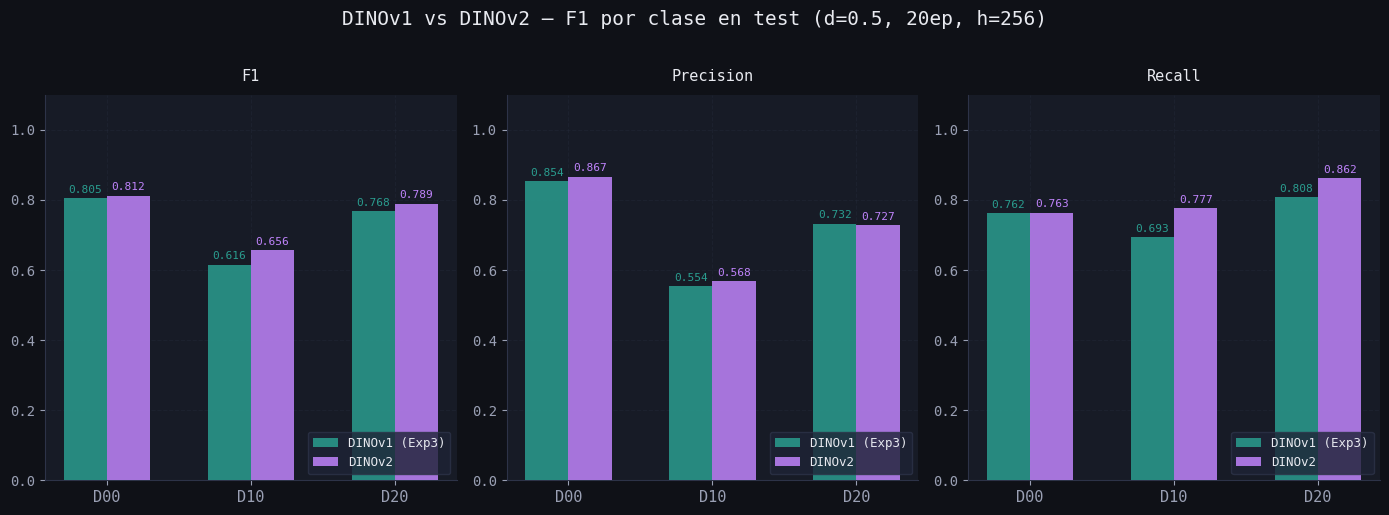

Figura guardada: dinov1_vs_v2_f1_clase.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), facecolor="#0F1117")
fig.suptitle("DINOv1 vs DINOv2 — F1 por clase en test (d=0.5, 20ep, h=256)",
             fontsize=14, color="#E8EAF0", y=1.02)

metrics_to_plot = ["f1", "precision", "recall"]
metric_titles   = ["F1", "Precision", "Recall"]

models  = [("DINOv1 (Exp3)", rep_v1, COLOR_V1), ("DINOv2", rep_v2, COLOR_V2)]
width   = 0.30
offsets = [-width / 2, width / 2]

for ax, metric, title in zip(axes, metrics_to_plot, metric_titles):
    x = np.arange(len(CLASSES))
    for (label, rep, color), off in zip(models, offsets):
        vals = [rep["test_metrics"][cls][metric] for cls in CLASSES]
        bars = ax.bar(x + off, vals, width, color=color, alpha=0.85,
                      label=label, zorder=3, linewidth=0)
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=8, color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(CLASSES, fontsize=11)
    ax.set_title(title, fontsize=11, color="#E8EAF0", pad=10)
    ax.set_ylim(0, 1.10)
    ax.legend(fontsize=9, facecolor="#1E2336", edgecolor="#2D3348",
              labelcolor="#E8EAF0", loc="lower right")

plt.tight_layout()
plt.savefig("dinov1_vs_v2_f1_clase.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("Figura guardada: dinov1_vs_v2_f1_clase.png")


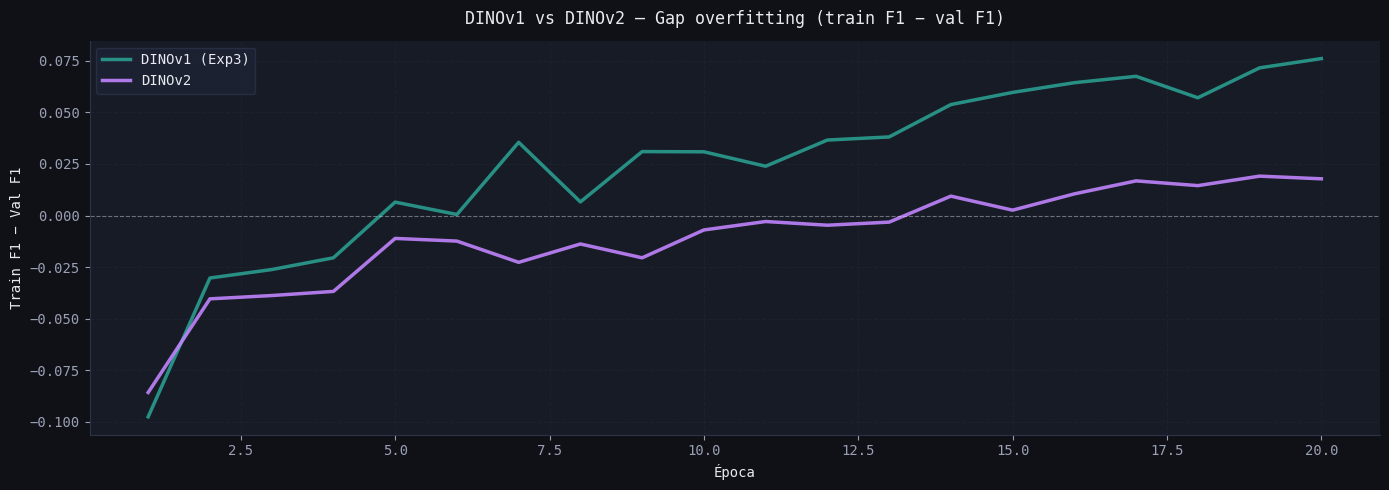

Figura guardada: dinov1_vs_v2_overfitting.png


In [ ]:
fig, ax = plt.subplots(figsize=(14, 5), facecolor="#0F1117")

for label, rep, color in [
    ("DINOv1 (Exp3)", rep_v1, COLOR_V1),
    ("DINOv2",        rep_v2, COLOR_V2),
]:
    epochs = [h["epoch"]                  for h in rep["history"]]
    gap    = [h["train_f1"] - h["val_f1"] for h in rep["history"]]
    ax.plot(epochs, gap, color=color, linewidth=2.5, label=label, alpha=0.9)

ax.axhline(0, color="#E8EAF0", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_title("DINOv1 vs DINOv2 — Gap overfitting (train F1 − val F1)", fontsize=12, color="#E8EAF0", pad=12)
ax.set_xlabel("Época", fontsize=10)
ax.set_ylabel("Train F1 − Val F1", fontsize=10)
ax.legend(fontsize=10, facecolor="#1E2336", edgecolor="#2D3348", labelcolor="#E8EAF0")

plt.tight_layout()
plt.savefig("dinov1_vs_v2_overfitting.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("Figura guardada: dinov1_vs_v2_overfitting.png")


## 9. Conclusión: DINOv1 vs DINOv2

Comparación directa con hiperparámetros idénticos (d=0.5, 20 épocas, hidden\_dim=256).

**Claves de interpretación:**
- Si DINOv2 sube **D10** notablemente → las features de mayor calidad atacan el cuello de botella.
- Si la mejora en Macro F1 viene solo de D00/D20 → el backbone más potente no resuelve la clase difícil.
- Si el gap de overfitting de DINOv2 es menor → el backbone implícitamente regulariza mejor.

---
## 10. Comparativa de 6 modelos: DINOv1, DINOv2, DINOv3-ViT, DINOv3-ConvNeXt, DINOv3-ViT-Large, DINOv3-ConvNeXt-Large

Todos entrenados con los mismos hiperparámetros (d=0.5, 20 épocas, hidden\_dim=256).
El único factor que varía es el **backbone de extracción de features**.

| | DINOv1 (Exp3) | DINOv2 | DINOv3-ViT | DINOv3-ConvNeXt | DINOv3-ViT-Large | DINOv3-ConvNeXt-Large |
|---|---|---|---|---|---|---|
| Backbone | ViT-S/16 DINOv1 | ViT-S/14 DINOv2 | ViT-B/16 DINOv3 | ConvNeXt-Tiny DINOv3 | ViT-L/16 DINOv3 | ConvNeXt-Large DINOv3 |
| Tamaño | light | light | light | light | **large** | **large** |
| Feat dim | 1536 | 1536 | 1536 | 1440 | 2048 | 2880 |
| Dropout | 0.5 | 0.5 | 0.5 | 0.5 | 0.5 | 0.5 |
| Épocas | 20 | 20 | 20 | 20 | 20 | 20 |
| Hidden dim | 256 | 256 | 256 | 256 | 256 | 256 |


In [ ]:
# ── Rutas a los reports de DINOv3 light ─────────────────────────────
#DINOV3_VIT_PATH       = r"C:\Users\pablo\Downloads\PASD\features\models\dinov3_vit\training_report_20_epochs_256_hidden.json"
#DINOV3_CONV_PATH      = r"C:\Users\pablo\Downloads\PASD\features\models\dinov3_convnext\training_report_20_epochs_256_hidden.json"
# ── Rutas a los reports de DINOv3 large ─────────────────────────────
#DINOV3_VIT_LARGE_PATH  = r"C:\Users\pablo\Downloads\PASD\features\models\dinov3_vit_large\training_report_20_epochs_256_hidden.json"
#DINOV3_CONV_LARGE_PATH = r"C:\Users\pablo\Downloads\PASD\features\models\dinov3_convnext_large\training_report_20_epochs_256_hidden.json"

# En Colab con Google Drive:
DINOV3_VIT_PATH       = "/content/drive/MyDrive/PASD BLOG/models/dinov3_ViT/training_report.json"
DINOV3_CONV_PATH      = "/content/drive/MyDrive/PASD BLOG/models/dinov3_ConvNext/training_report.json"
DINOV3_VIT_LARGE_PATH  = "/content/drive/MyDrive/PASD BLOG/models/dinov3-vit-large/training_report.json"
DINOV3_CONV_LARGE_PATH = "/content/drive/MyDrive/PASD BLOG/models/dinov3-convnext-large/training_report.json"

with open(DINOV3_VIT_PATH, encoding="utf-8") as f:
    rep_v3_vit = json.load(f)
with open(DINOV3_CONV_PATH, encoding="utf-8") as f:
    rep_v3_conv = json.load(f)
with open(DINOV3_VIT_LARGE_PATH, encoding="utf-8") as f:
    rep_v3_vit_large = json.load(f)
with open(DINOV3_CONV_LARGE_PATH, encoding="utf-8") as f:
    rep_v3_conv_large = json.load(f)

COLOR_V3_VIT     = "#FB8500"   # naranja         — DINOv3-ViT (light)
COLOR_V3_CONV    = "#E63946"   # rojo            — DINOv3-ConvNeXt (light)
COLOR_V3_VIT_LG  = "#FFD166"   # amarillo dorado — DINOv3-ViT-Large
COLOR_V3_CONV_LG = "#06D6A0"   # verde menta     — DINOv3-ConvNeXt-Large

models_6 = [
    ("DINOv1 (Exp3)",         rep_v1,            COLOR_V1),
    ("DINOv2",                rep_v2,            COLOR_V2),
    ("DINOv3-ViT",            rep_v3_vit,        COLOR_V3_VIT),
    ("DINOv3-ConvNeXt",       rep_v3_conv,       COLOR_V3_CONV),
    ("DINOv3-ViT-Large",      rep_v3_vit_large,  COLOR_V3_VIT_LG),
    ("DINOv3-ConvNeXt-Large", rep_v3_conv_large, COLOR_V3_CONV_LG),
]

for label, rep, _ in models_6:
    n_ep = len(rep["history"])
    mf1  = rep["test_metrics"]["macro_f1"]
    print(f"  {label:<26}: {n_ep} épocas | Macro F1 test = {mf1:.4f} ✅")


  DINOv1 (Exp3)             : 20 épocas | Macro F1 test = 0.7298 ✅
  DINOv2                    : 20 épocas | Macro F1 test = 0.7523 ✅
  DINOv3-ViT                : 20 épocas | Macro F1 test = 0.7335 ✅
  DINOv3-ConvNeXt           : 20 épocas | Macro F1 test = 0.7250 ✅
  DINOv3-ViT-Large          : 20 épocas | Macro F1 test = 0.7314 ✅
  DINOv3-ConvNeXt-Large     : 20 épocas | Macro F1 test = 0.7361 ✅


In [ ]:
print(f"{'Modelo':<24} {'Macro F1':>9} {'D00 F1':>8} {'D10 F1':>8} {'D20 F1':>8} {'Exact Acc':>10} {'Train F1':>10} {'Val loss':>10} {'Mejor ep':>9}")
print("─" * 110)

for label, rep, _ in models_6:
    tm       = rep["test_metrics"]
    hist     = rep["history"]
    best_ep  = max(hist, key=lambda h: h["val_f1"])["epoch"]
    print(
        f"  {label:<22} "
        f"{tm['macro_f1']:>9.4f} "
        f"{tm['D00']['f1']:>8.4f} "
        f"{tm['D10']['f1']:>8.4f} "
        f"{tm['D20']['f1']:>8.4f} "
        f"{tm['exact_accuracy']:>10.4f} "
        f"{hist[-1]['train_f1']:>10.4f} "
        f"{hist[-1]['val_loss']:>10.4f} "
        f"{best_ep:>9} "
    )


Modelo                    Macro F1   D00 F1   D10 F1   D20 F1  Exact Acc   Train F1   Val loss  Mejor ep
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  DINOv1 (Exp3)             0.7298   0.8053   0.6157   0.7684     0.5004     0.8216     0.5401        11 
  DINOv2                    0.7523   0.8119   0.6562   0.7890     0.5208     0.7756     0.4940        13 
  DINOv3-ViT                0.7335   0.7939   0.6345   0.7723     0.5027     0.7921     0.5156         9 
  DINOv3-ConvNeXt           0.7250   0.7931   0.6192   0.7628     0.4867     0.7609     0.5293        20 
  DINOv3-ViT-Large          0.7314   0.7857   0.6469   0.7615     0.4905     0.7968     0.4939        10 
  DINOv3-ConvNeXt-Large     0.7361   0.7936   0.6256   0.7890     0.5034     0.7979     0.4985         9 


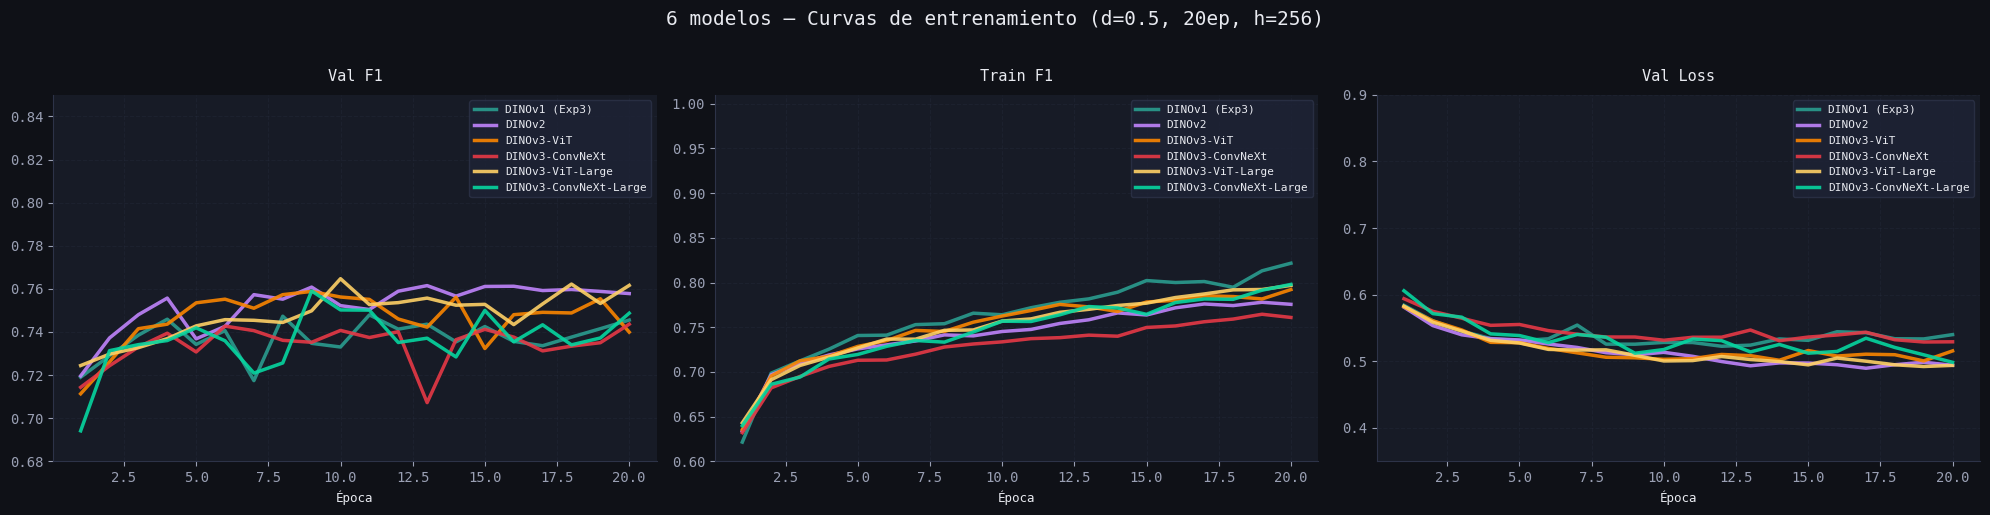

Figura guardada: 6modelos_curvas.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), facecolor="#0F1117")
fig.suptitle("6 modelos — Curvas de entrenamiento (d=0.5, 20ep, h=256)",
             fontsize=14, color="#E8EAF0", y=1.02)

titles   = ["Val F1", "Train F1", "Val Loss"]
keys_y   = ["val_f1", "train_f1", "val_loss"]
y_limits = [(0.68, 0.85), (0.60, 1.01), (0.35, 0.90)]

for ax, title, key, ylim in zip(axes, titles, keys_y, y_limits):
    for label, rep, color in models_6:
        epochs = [h["epoch"] for h in rep["history"]]
        values = [h[key]     for h in rep["history"]]
        ax.plot(epochs, values, color=color, linewidth=2.5, label=label, alpha=0.9)

    ax.set_title(title, fontsize=11, color="#E8EAF0", pad=10)
    ax.set_xlabel("Época", fontsize=9)
    ax.set_ylim(ylim)
    ax.legend(fontsize=8, facecolor="#1E2336", edgecolor="#2D3348",
              labelcolor="#E8EAF0", loc="best")

plt.tight_layout()
plt.savefig("6modelos_curvas.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("Figura guardada: 6modelos_curvas.png")


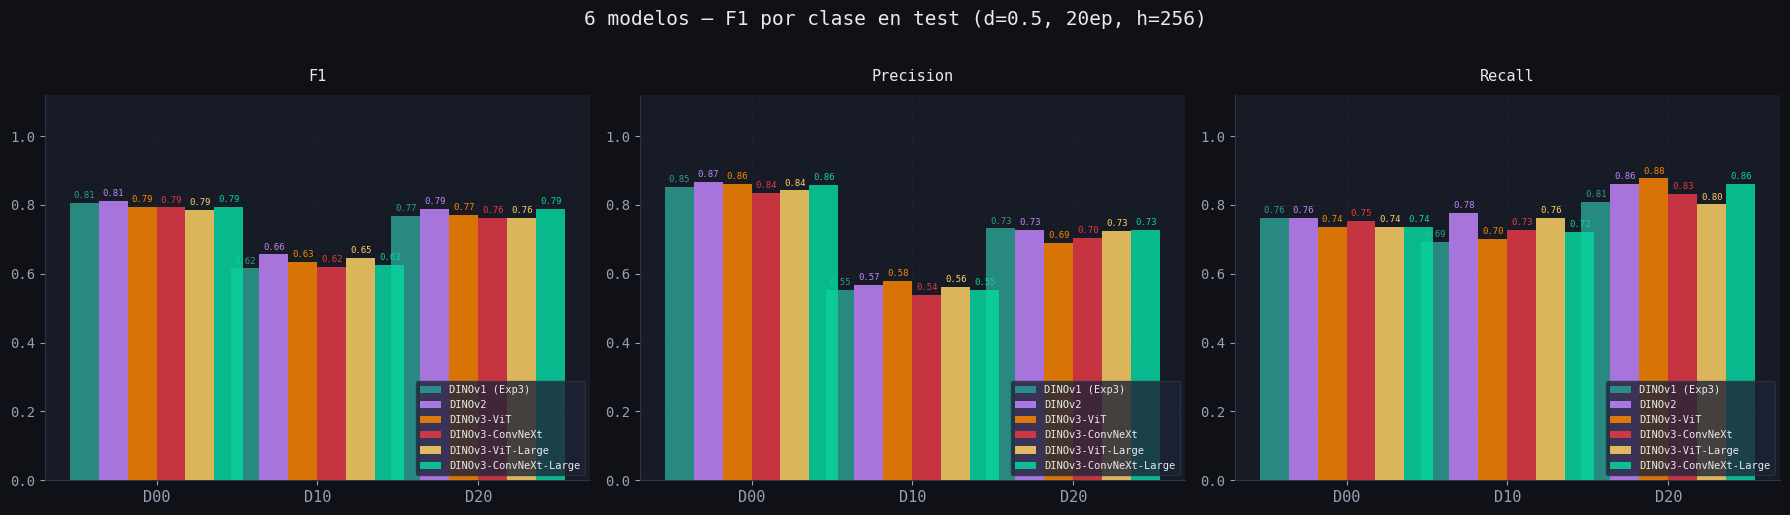

Figura guardada: 6modelos_f1_clase.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor="#0F1117")
fig.suptitle("6 modelos — F1 por clase en test (d=0.5, 20ep, h=256)",
             fontsize=14, color="#E8EAF0", y=1.02)

metrics_to_plot = ["f1", "precision", "recall"]
metric_titles   = ["F1", "Precision", "Recall"]

n_models = len(models_6)
width    = 0.18
offsets  = np.linspace(-(n_models - 1) / 2, (n_models - 1) / 2, n_models) * width

for ax, metric, title in zip(axes, metrics_to_plot, metric_titles):
    x = np.arange(len(CLASSES))
    for (label, rep, color), off in zip(models_6, offsets):
        vals = [rep["test_metrics"][cls][metric] for cls in CLASSES]
        bars = ax.bar(x + off, vals, width, color=color, alpha=0.85,
                      label=label, zorder=3, linewidth=0)
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.008,
                    f"{h:.2f}", ha="center", va="bottom", fontsize=6.5, color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(CLASSES, fontsize=11)
    ax.set_title(title, fontsize=11, color="#E8EAF0", pad=10)
    ax.set_ylim(0, 1.12)
    ax.legend(fontsize=7.5, facecolor="#1E2336", edgecolor="#2D3348",
              labelcolor="#E8EAF0", loc="lower right")

plt.tight_layout()
plt.savefig("6modelos_f1_clase.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("Figura guardada: 6modelos_f1_clase.png")


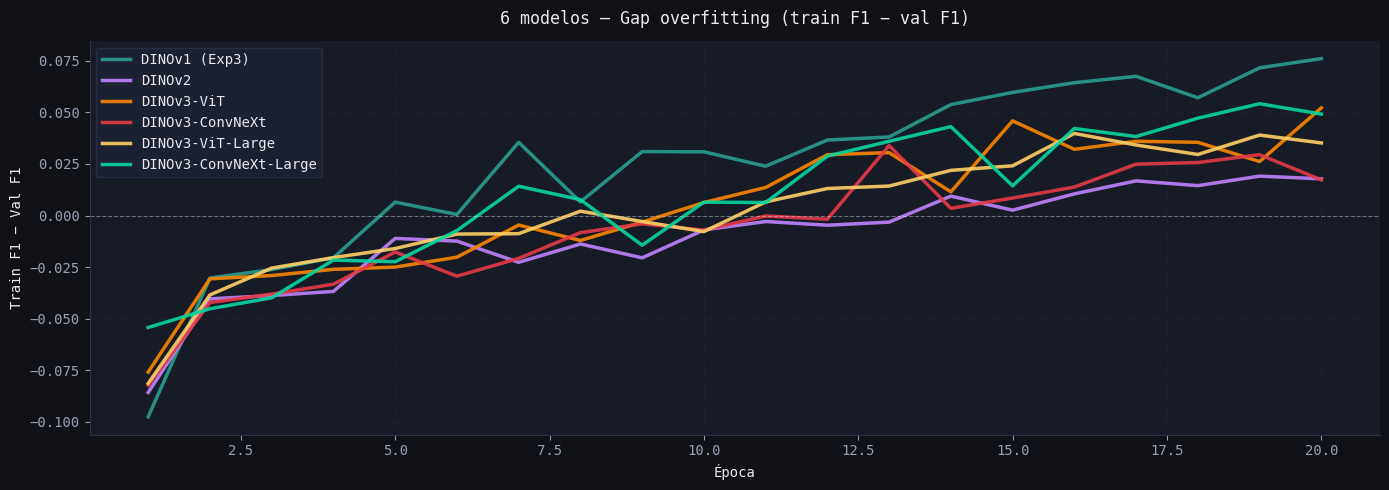

Figura guardada: 6modelos_overfitting.png


In [ ]:
fig, ax = plt.subplots(figsize=(14, 5), facecolor="#0F1117")

for label, rep, color in models_6:
    epochs = [h["epoch"]                  for h in rep["history"]]
    gap    = [h["train_f1"] - h["val_f1"] for h in rep["history"]]
    ax.plot(epochs, gap, color=color, linewidth=2.5, label=label, alpha=0.9)

ax.axhline(0, color="#E8EAF0", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_title("6 modelos — Gap overfitting (train F1 − val F1)", fontsize=12, color="#E8EAF0", pad=12)
ax.set_xlabel("Época", fontsize=10)
ax.set_ylabel("Train F1 − Val F1", fontsize=10)
ax.legend(fontsize=10, facecolor="#1E2336", edgecolor="#2D3348", labelcolor="#E8EAF0")

plt.tight_layout()
plt.savefig("6modelos_overfitting.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("Figura guardada: 6modelos_overfitting.png")


## 11. Conclusión: los seis modelos

Comparativa controlada con hiperparámetros idénticos (d=0.5, 20 épocas, hidden\_dim=256); el único factor que varía es el backbone de extracción de features.

**Ejes de análisis:**
- **Macro F1**: ¿mejora global al escalar el backbone a variantes *large*?
- **D10 F1**: cuello de botella persistente — ¿algún backbone lo rompe?
- **Gap overfitting**: un backbone más potente puede regularizar implícitamente.
- **DINOv3-ViT vs DINOv3-ConvNeXt** (light): ¿Transformer o convolucional a igual tamaño?
- **Large vs Light**: ¿la ganancia de calidad justifica duplicar/triplicar la dimensión de features?


---
## 12. DINOv2 Frozen (MLP) vs DINOv2 Fine-tuneado (end-to-end)

Comparamos dos estrategias radicalmente distintas de aprovechar DINOv2:

| | **DINOv2 Frozen** | **DINOv2 Fine-tuneado** |
|---|---|---|
| Estrategia | Feature extraction + MLP | End-to-end (backprop completo) |
| Backbone | **Congelado** — sin gradientes | **Parcialmente descongelado** (N bloques ViT) |
| Parámetros entrenados | Solo cabeza MLP | Cabeza lineal + últimos bloques ViT |
| Cabeza | MLP (h=256, d=0.5, 20 ep) | Clasificador lineal con BCE ponderado |
| Coste de inferencia | Extracción previa de features | Forward pass completo cada imagen |

**Hipótesis:** al descongelar parte del backbone, DINOv2 adapta sus representaciones
al dominio de grietas (RDD2022), lo que debería atacar el cuello de botella de D10.

In [1]:
import os
for root, dirs, files in os.walk("/content/drive"):
    for file in files:
        if file == "training_report.json":
            print(os.path.join(root, file))

In [2]:
import os

for root, dirs, files in os.walk("/content/drive/.shortcut-targets-by-id"):
    for file in files:
        if file == "training_report.json":
            print(os.path.join(root, file))


In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
# ── Ruta al report del DINOv2 fine-tuneado (generado por evaluate_finetuned.py) ──
# En local (Windows):
#DINOV2_FT_PATH = r"C:\Users\pablo\Desktop\Uni 23 24\Curso 3\2o CUATRI\PASD\BLOG\features\models\dinov2-finetuned\training_report.json"
import json
# En Colab con Google Drive:
DINOV2_FT_PATH = "/content/drive/.shortcut-targets-by-id/1D0guHvrXAaC11dvDKudeWdREl16HBY-N/dinov2-finetuned/training_report.json"

with open(DINOV2_FT_PATH, encoding="utf-8") as f:
    rep_v2_ft = json.load(f)

# En Colab con Google Drive:
DINOV2_PATH = "/content/drive/.shortcut-targets-by-id/1lRbVdymJtSSLElk9qSWJkmxNPxm9-R8d/dinov2_MLP/training_report.json"

with open(DINOV2_PATH, encoding="utf-8") as f:
    rep_v2 = json.load(f)

COLOR_V2_FT = "#F72585"   # rosa neón — DINOv2 fine-tuneado

# rep_v2 ya está cargado de la sección 8 (DINOv2 frozen)
mf1_frozen = rep_v2["test_metrics"]["macro_f1"]
mf1_ft     = rep_v2_ft["test_metrics"]["macro_f1"]
best_ep_ft = rep_v2_ft.get("best_epoch", "N/A")
args_ft    = rep_v2_ft.get("args", {})

print(f"  DINOv2 Frozen (MLP):     Macro F1 test = {mf1_frozen:.4f} ✅")
print(f"  DINOv2 Fine-tuneado:     Macro F1 test = {mf1_ft:.4f} ✅")
print(f"  Mejor época (ft):        {best_ep_ft}")
if args_ft:
    print(f"  Bloques descongelados:   {args_ft.get('n_unfrozen_blocks', 'N/A')}")
    print(f"  Dropout (ft):            {args_ft.get('dropout', 'N/A')}")
delta = mf1_ft - mf1_frozen
sign  = "+" if delta >= 0 else ""
print(f"  Delta Macro F1:          {sign}{delta:.4f}")

  DINOv2 Frozen (MLP):     Macro F1 test = 0.7523 ✅
  DINOv2 Fine-tuneado:     Macro F1 test = 0.7982 ✅
  Mejor época (ft):        6
  Bloques descongelados:   2
  Dropout (ft):            0.3
  Delta Macro F1:          +0.0459


In [5]:
print(f"{"Modelo":<32} {"Macro F1":>9} {"D00 F1":>8} {"D10 F1":>8} {"D20 F1":>8} {"Exact Acc":>10}")
print("─" * 82)

for label, rep in [
    ("DINOv2 Frozen (MLP)",    rep_v2),
    ("DINOv2 Fine-tuneado",    rep_v2_ft),
]:
    tm = rep["test_metrics"]
    print(
        f"  {label:<30} "
        f"{tm['macro_f1']:>9.4f} "
        f"{tm['D00']['f1']:>8.4f} "
        f"{tm['D10']['f1']:>8.4f} "
        f"{tm['D20']['f1']:>8.4f} "
        f"{tm['exact_accuracy']:>10.4f}"
    )

print()
delta_d10 = rep_v2_ft["test_metrics"]["D10"]["f1"] - rep_v2["test_metrics"]["D10"]["f1"]
sign = "+" if delta_d10 >= 0 else ""
print(f"  Delta D10 F1: {sign}{delta_d10:.4f}  ← cuello de botella")

Modelo                            Macro F1   D00 F1   D10 F1   D20 F1  Exact Acc
──────────────────────────────────────────────────────────────────────────────────
  DINOv2 Frozen (MLP)               0.7523   0.8119   0.6562   0.7890     0.5208
  DINOv2 Fine-tuneado               0.7982   0.8345   0.7278   0.8323     0.6141

  Delta D10 F1: +0.0716  ← cuello de botella


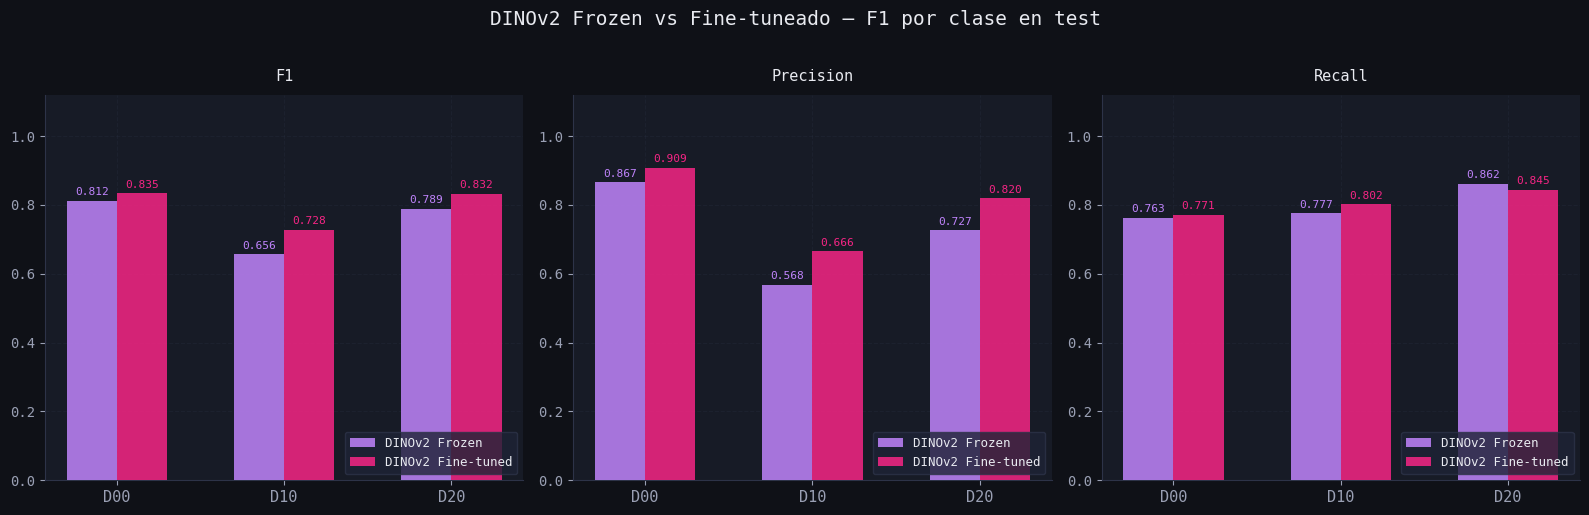

Figura guardada: dinov2_frozen_vs_ft_f1_clase.png


In [10]:


fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor="#0F1117")
fig.suptitle("DINOv2 Frozen vs Fine-tuneado — F1 por clase en test",
             fontsize=14, color="#E8EAF0", y=1.02)

metrics_to_plot = ["f1", "precision", "recall"]
metric_titles   = ["F1", "Precision", "Recall"]

models_ft = [
    ("DINOv2 Frozen",     rep_v2,    COLOR_V2),
    ("DINOv2 Fine-tuned", rep_v2_ft, COLOR_V2_FT),
]
width   = 0.30
offsets = [-width / 2, width / 2]

for ax, metric, title in zip(axes, metrics_to_plot, metric_titles):
    x = np.arange(len(CLASSES))
    for (label, rep, color), off in zip(models_ft, offsets):
        vals = [rep["test_metrics"][cls][metric] for cls in CLASSES]
        bars = ax.bar(x + off, vals, width, color=color, alpha=0.85,
                      label=label, zorder=3, linewidth=0)
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=8, color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(CLASSES, fontsize=11)
    ax.set_title(title, fontsize=11, color="#E8EAF0", pad=10)
    ax.set_ylim(0, 1.12)
    ax.legend(fontsize=9, facecolor="#1E2336", edgecolor="#2D3348",
              labelcolor="#E8EAF0", loc="lower right")

plt.tight_layout()
plt.savefig("dinov2_frozen_vs_ft_f1_clase.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("Figura guardada: dinov2_frozen_vs_ft_f1_clase.png")

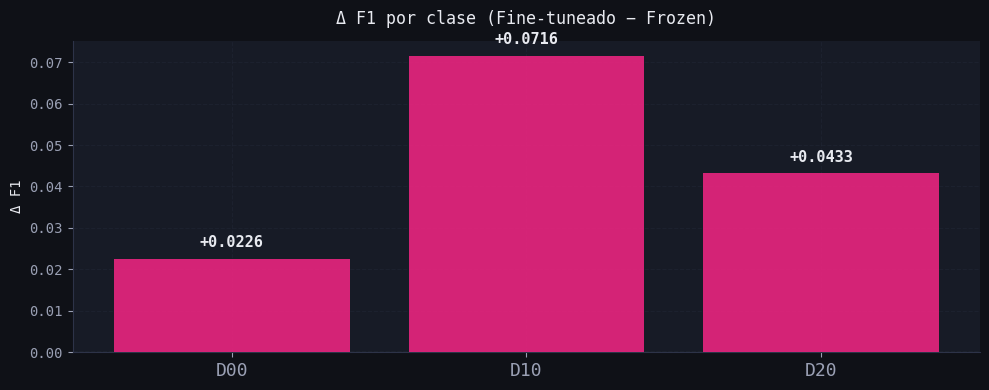

Figura guardada: dinov2_frozen_vs_ft_delta_f1.png


In [11]:
# Delta F1 por clase: Fine-tuneado − Frozen
delta_f1 = [
    rep_v2_ft["test_metrics"][cls]["f1"] - rep_v2["test_metrics"][cls]["f1"]
    for cls in CLASSES
]

fig, ax = plt.subplots(figsize=(10, 4), facecolor="#0F1117")
bar_colors = [COLOR_V2_FT if d >= 0 else "#E63946" for d in delta_f1]
bars = ax.bar(CLASSES, delta_f1, color=bar_colors, alpha=0.85, zorder=3, linewidth=0)

for bar, d in zip(bars, delta_f1):
    sign = "+" if d >= 0 else ""
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        d + (0.002 if d >= 0 else -0.005),
        f"{sign}{d:.4f}",
        ha="center",
        va="bottom" if d >= 0 else "top",
        fontsize=11, color="#E8EAF0", fontweight="bold",
    )

ax.axhline(0, color="#E8EAF0", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_title("\u0394 F1 por clase (Fine-tuneado \u2212 Frozen)",
             fontsize=12, color="#E8EAF0", pad=12)
ax.set_ylabel("\u0394 F1", fontsize=10)
ax.set_xticks(range(len(CLASSES)))
ax.set_xticklabels(CLASSES, fontsize=13)

plt.tight_layout()
plt.savefig("dinov2_frozen_vs_ft_delta_f1.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("Figura guardada: dinov2_frozen_vs_ft_delta_f1.png")

In [12]:
# Curvas de entrenamiento — solo si ambos reports incluyen historial epoch a epoch
has_history_frozen = "history" in rep_v2
has_history_ft     = "history" in rep_v2_ft

if has_history_frozen and has_history_ft:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5), facecolor="#0F1117")
    fig.suptitle("DINOv2 Frozen vs Fine-tuneado — Curvas de entrenamiento",
                 fontsize=14, color="#E8EAF0", y=1.02)

    titles   = ["Val F1", "Train F1", "Val Loss"]
    keys_y   = ["val_f1", "train_f1", "val_loss"]
    y_limits = [(0.68, 0.90), (0.60, 1.01), (0.30, 0.90)]

    for ax, title, key, ylim in zip(axes, titles, keys_y, y_limits):
        for label, rep, color in [
            ("DINOv2 Frozen",     rep_v2,    COLOR_V2),
            ("DINOv2 Fine-tuned", rep_v2_ft, COLOR_V2_FT),
        ]:
            epochs = [h["epoch"] for h in rep["history"]]
            values = [h[key]     for h in rep["history"]]
            ax.plot(epochs, values, color=color, linewidth=2.5, label=label, alpha=0.9)

        ax.set_title(title, fontsize=11, color="#E8EAF0", pad=10)
        ax.set_xlabel("\u00c9poca", fontsize=9)
        ax.set_ylim(ylim)
        ax.legend(fontsize=9, facecolor="#1E2336", edgecolor="#2D3348",
                  labelcolor="#E8EAF0", loc="best")

    plt.tight_layout()
    plt.savefig("dinov2_frozen_vs_ft_curvas.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
    plt.show()
    print("Figura guardada: dinov2_frozen_vs_ft_curvas.png")
else:
    missing = []
    if not has_history_frozen: missing.append("Frozen (MLP)")
    if not has_history_ft:     missing.append("Fine-tuneado")
    print(f"[INFO] Sin historial epoch-a-epoch para: {", ".join(missing)}")
    print("       Para ver curvas, usa el report generado durante el entrenamiento")
    print("       (finetune_dinov2.py), no el de evaluate_finetuned.py.")

[INFO] Sin historial epoch-a-epoch para: Fine-tuneado
       Para ver curvas, usa el report generado durante el entrenamiento
       (finetune_dinov2.py), no el de evaluate_finetuned.py.


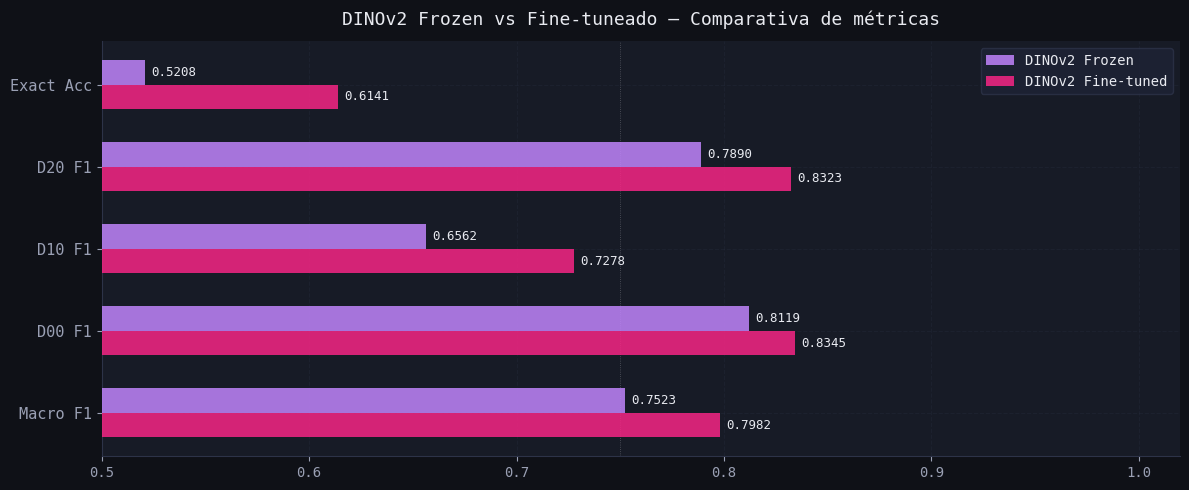

Figura guardada: dinov2_frozen_vs_ft_resumen.png


In [13]:
# Resumen visual — barras horizontales comparando todas las métricas
metrics_summary = {
    "Macro F1": [rep_v2["test_metrics"]["macro_f1"],          rep_v2_ft["test_metrics"]["macro_f1"]],
    "D00 F1":   [rep_v2["test_metrics"]["D00"]["f1"],         rep_v2_ft["test_metrics"]["D00"]["f1"]],
    "D10 F1":   [rep_v2["test_metrics"]["D10"]["f1"],         rep_v2_ft["test_metrics"]["D10"]["f1"]],
    "D20 F1":   [rep_v2["test_metrics"]["D20"]["f1"],         rep_v2_ft["test_metrics"]["D20"]["f1"]],
    "Exact Acc":[rep_v2["test_metrics"]["exact_accuracy"],    rep_v2_ft["test_metrics"]["exact_accuracy"]],
}

labels  = list(metrics_summary.keys())
vals_fr = [metrics_summary[k][0] for k in labels]
vals_ft_list = [metrics_summary[k][1] for k in labels]

y      = np.arange(len(labels))
height = 0.30

fig, ax = plt.subplots(figsize=(12, 5), facecolor="#0F1117")
bars_fr = ax.barh(y + height / 2, vals_fr,      height,
                  color=COLOR_V2,    alpha=0.85, label="DINOv2 Frozen",     zorder=3)
bars_ft = ax.barh(y - height / 2, vals_ft_list, height,
                  color=COLOR_V2_FT, alpha=0.85, label="DINOv2 Fine-tuned", zorder=3)

for bars, vals in [(bars_fr, vals_fr), (bars_ft, vals_ft_list)]:
    for bar, v in zip(bars, vals):
        ax.text(v + 0.003, bar.get_y() + bar.get_height() / 2,
                f"{v:.4f}", va="center", fontsize=9, color="#E8EAF0")

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlim(0.50, 1.02)
ax.set_title("DINOv2 Frozen vs Fine-tuneado — Comparativa de m\u00e9tricas",
             fontsize=13, color="#E8EAF0", pad=12)
ax.legend(fontsize=10, facecolor="#1E2336", edgecolor="#2D3348", labelcolor="#E8EAF0")
ax.axvline(0.75, color="#E8EAF0", linewidth=0.6, linestyle=":", alpha=0.3)

plt.tight_layout()
plt.savefig("dinov2_frozen_vs_ft_resumen.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("Figura guardada: dinov2_frozen_vs_ft_resumen.png")

## 13. Conclusión: DINOv2 Frozen vs Fine-tuneado

El fine-tuning end-to-end permite adaptar las representaciones internas de DINOv2
al dominio específico de grietas en pavimento, en lugar de usarlo como extractor genérico.

**Ejes de análisis:**
- **Δ Macro F1 global**: ¿compensa el coste de fine-tuning frente al backbone congelado?
- **Δ D10 F1**: clase con peor rendimiento histórico — ¿la adaptación del backbone la mejora?
- **Δ D00 / D20**: clases con mejor baseline — ¿el fine-tuning las estabiliza o las degrada?
- **Exact Accuracy**: métrica más estricta (todas las etiquetas correctas por imagen).

**Interpretación esperada:**
- Si D10 mejora significativamente → el fine-tuning adapta features a texturas difusas de grietas longitudinales.
- Si la mejora viene solo de D00/D20 → el dominio de grietas no es suficientemente distinto de ImageNet.
- Si el fine-tuneado tiene peor exact accuracy con mejor Macro F1 → gana en clases difíciles pero pierde consistencia multilabel.
